# CIEM5220 – SRE Project Part 1, Question 4: Random Vibrations of the OWT

**Model and assumptions** (as prescribed in the assignment)

- The OWT is **rigidly clamped** to the top of the soil; dynamic soil–structure interaction is
  neglected. The seismic excitation enters as a **prescribed base motion** equal to the soil
  surface motion obtained in Q3 (bedrock motion amplified through the layered soil).
- The two dynamic loads, **seismic** and **wave** are assumed to be **uncorrelated**, so their
  response variances add. The **mean** response comes only from the constant wind force `F_w`.
- Wave loading uses **Morison's equation, inertia term only** (drag neglected).
- The response is treated as a **stationary Gaussian** process; for any response quantity `Y`
  with frequency response function `H_Y(ω)` and input one-sided PSD `S_in(f)`,

$$\sigma_Y^2=\int_0^\infty |H_Y(f)|^2\,S_\text{in}(f)\,df,\qquad
  \mu_Y=\text{(static response to } F_w).$$


## Parameters and structural model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, correlate, coherence
from scipy.fft import rfft, rfftfreq
from scipy.linalg import eigh
from scipy.optimize import brentq
from scipy.stats import norm
from pathlib import Path

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
g = 9.81
images = Path('images')
images.mkdir(exist_ok=True)

# Group parameter digits A..G
A, B, C, D, E, F, G = 6, 6, 1, 1, 2, 5, 7

# ---- Tower (steel, Euler-Bernoulli) ----
E_t, rho_t, xi_t = 210e9, 7850., 0.001      # Young's modulus, density, structural damping ratio
M_top, J_top     = (800 + 10*F)*1e3, 300e6  # nacelle+rotor mass and rotary inertia at the top

def section(d_out, d_in):
    """Area and second moment of area of a hollow circular section."""
    A_  = np.pi/4  * (d_out**2 - d_in**2)
    I_  = np.pi/64 * (d_out**4 - d_in**4)
    return A_, I_

# Per Figure 1: submerged segment uses cross-section 1 (larger); the segment in air uses
# cross-section 2 (smaller). The base sits at the seabed / top of soil layer 1.
A_sub, I_sub = section(9.1, 8.96)   # cross-section 1  -> submerged length H_water
A_air, I_air = section(7.1, 7.0)    # cross-section 2  -> length in air H_air
H_water = 30 + F                    # submerged length = water depth   = 35 m
H_air   = 140 + A                   # length in air                    = 146 m
H_tower = H_water + H_air           # total tower height               = 181 m
F_w     = 2e5                       # constant wind force at the top [N]

# Soil column (3 visco-elastic layers on bedrock),
H1, H2, H3 = 2 + B, 58 + G, 38 + F
G1, G2, G3 = (100 + 10*F)*1e6, (100 + 10*D)*1e6, (100 + 10*E)*1e6
rho1, rho2, rho3 = 1650., 1850., 1900.
eta1, eta2, eta3 = 1000. + 10*C, 1000. + 10*E, 1000. + 10*D
z1, z2, z3 = H1, H1 + H2, H1 + H2 + H3   # depths of the layer interfaces / bedrock

print(f"OWT total height = {H_tower:.0f} m (submerged {H_water:.0f} + air {H_air:.0f})")
print(f"top mass M = {M_top:,.0f} kg, J = {J_top:,.0f} kg m^2, structural damping xi_t = {xi_t}")

OWT total height = 181 m (submerged 35 + air 146)
top mass M = 850,000 kg, J = 300,000,000 kg m^2, structural damping xi_t = 0.001


## Input 1 — Seismic bedrock PSD (principal horizontal component)

The bedrock excitation is taken from the Groningen recording at ~100 m depth
(`NL.G192..ALL.2018-01-08.dat`, columns `t, hor1, hor2, vert` in units of *g*). Following
`PSD.ipynb`, the PSD is estimated as the Fourier transform of the auto-correlation
(Wiener–Khinchin). Two points are handled explicitly here:

1. **Principal horizontal component.** Rather than picking one recorded axis, the dominant
   horizontal direction is obtained as the major principal axis of the two horizontal channels
   (the eigenvector of their covariance with the largest eigenvalue). This is the strongest
   horizontal shaking direction and is used as the seismic input.
2. **One-sided convention.** `PSD.ipynb` returns a two-sided PSD (it does not multiply by 2),
   which integrates over the positive-frequency axis to half the variance. It is therefore
   doubled here to obtain a one-sided PSD that integrates to the full signal variance
   (verified below by Parseval's theorem). The signal is also converted from *g* to m/s².

PGA (principal horizontal) = 0.0341 g
Parseval check: int(PSD) df = 1.764e-04 vs signal variance = 1.763e-04 (m/s^2)^2  -> match


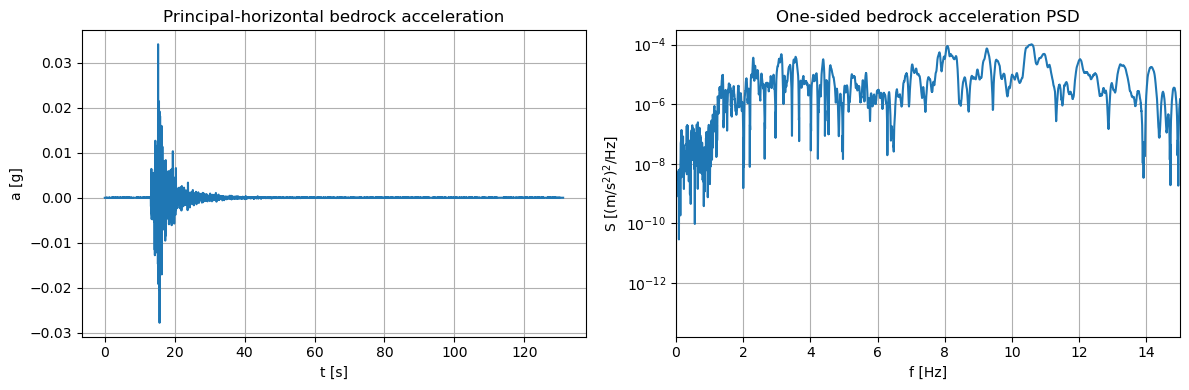

In [2]:
data = np.loadtxt('NL.G192..ALL.2018-01-08.dat')
t_sig = data[:, 0]
dt_s  = t_sig[1] - t_sig[0]
fs    = 1/dt_s

def highpass(x, cutoff=0.1, order=4):
    """Butterworth high-pass to remove sub-0.1 Hz instrument drift."""
    b, a = butter(order, cutoff/(0.5*fs), btype='high')
    return filtfilt(b, a, x)

hor1, hor2, vert = highpass(data[:, 1]), highpass(data[:, 2]), highpass(data[:, 3])

# Principal horizontal = projection of the two horizontals on their major principal axis
Hh = np.vstack([hor1 - hor1.mean(), hor2 - hor2.mean()])
_, V = np.linalg.eigh(np.cov(Hh))
prin    = V[:, -1] @ Hh        # principal horizontal acceleration [g]
prin_ms = prin * g             # -> m/s^2

# PSD via auto-correlation, doubled to a ONE-SIDED spectrum
corr = correlate(prin_ms, prin_ms, mode='full') * dt_s
norm_lag = np.array([len(prin_ms) - abs(l)
                     for l in range(-len(prin_ms)+1, len(prin_ms))]) * dt_s
PSD_seis = 2 * np.abs(rfft(corr/norm_lag)) * dt_s
f_seis   = rfftfreq(len(corr), dt_s)

def S_bedrock(f):
    """One-sided bedrock acceleration PSD [(m/s^2)^2/Hz] at frequency f [Hz]."""
    return np.interp(f, f_seis, PSD_seis, left=0, right=0)

print(f"PGA (principal horizontal) = {np.abs(prin).max():.4f} g")
print(f"Parseval check: int(PSD) df = {np.trapezoid(PSD_seis, f_seis):.3e} "
      f"vs signal variance = {np.var(prin_ms):.3e} (m/s^2)^2  -> match")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t_sig, prin)
ax[0].set(title='Principal-horizontal bedrock acceleration', xlabel='t [s]', ylabel='a [g]')
ax[1].semilogy(f_seis, PSD_seis)
ax[1].set(title='One-sided bedrock acceleration PSD', xlabel='f [Hz]',
          ylabel='S [(m/s$^2$)$^2$/Hz]', xlim=(0, 15))
plt.tight_layout()
fig.savefig(images / 'q4_bedrock_signal_psd.png', bbox_inches='tight', dpi=200)
plt.show()

## Input 2 — Soil-surface amplification FRF (from Q3)

For 1-D vertically propagating SH waves, the horizontal motion in layer *j* is
$u_j(z)=A_j\sin(k_j z)+B_j\cos(k_j z)$ with complex wavenumber
$k_j=\omega\sqrt{\rho_j/G_j^{*}}$ and complex shear modulus $G_j^{*}=G_j+i\omega\eta_j$.
Imposing a stress-free surface, displacement/stress continuity at the two interfaces, and a unit
displacement at bedrock yields a 6×6 system. The transfer function below returns the **surface /
bedrock** displacement ratio $H_\text{soil}(0,\omega)=u(0)/u(z_3)$; because the ratio is the same
for displacement, velocity and acceleration, it can be applied directly to the bedrock
*acceleration* PSD.

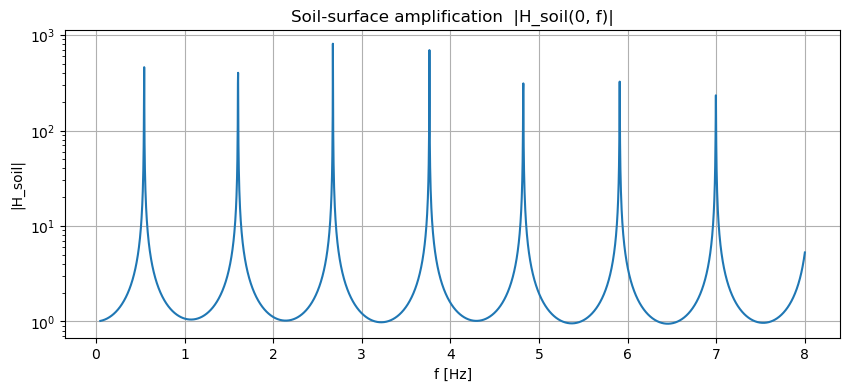

peak surface amplification ~812x at f = 2.67 Hz


In [3]:
def soil_matrix(om):
    """6x6 system matrix for the 3-layer SH column at angular frequency om."""
    G1c, G2c, G3c = G1 + 1j*om*eta1, G2 + 1j*om*eta2, G3 + 1j*om*eta3
    k1 = om*np.sqrt(rho1/G1c); k2 = om*np.sqrt(rho2/G2c); k3 = om*np.sqrt(rho3/G3c)
    M = np.zeros((6, 6), complex)
    M[0, 0]   = k1                                                            # stress-free surface
    M[1, 0:4] = [np.sin(k1*z1), np.cos(k1*z1), -np.sin(k2*z1), -np.cos(k2*z1)]          # u  cont. @ z1
    M[2, 0:4] = [G1c*k1*np.cos(k1*z1), -G1c*k1*np.sin(k1*z1),
                 -G2c*k2*np.cos(k2*z1),  G2c*k2*np.sin(k2*z1)]                          # tau cont. @ z1
    M[3, 2:6] = [np.sin(k2*z2), np.cos(k2*z2), -np.sin(k3*z2), -np.cos(k3*z2)]          # u  cont. @ z2
    M[4, 2:6] = [G2c*k2*np.cos(k2*z2), -G2c*k2*np.sin(k2*z2),
                 -G3c*k3*np.cos(k3*z2),  G3c*k3*np.sin(k3*z2)]                          # tau cont. @ z2
    M[5, 4:6] = [np.sin(k3*z3), np.cos(k3*z3)]                                          # u(z3)=bedrock
    return M

def H_soil(om):
    """Surface/bedrock displacement amplification u(0)/u(z3)."""
    rhs = np.array([0, 0, 0, 0, 0, 1.0], complex)
    return np.linalg.solve(soil_matrix(om), rhs)[1]    # B1 = u(z=0)

f_soil = np.linspace(0.05, 8, 4000)
H_soil_abs = np.array([abs(H_soil(2*np.pi*f)) for f in f_soil])
plt.figure()
plt.semilogy(f_soil, H_soil_abs)
plt.title('Soil-surface amplification  |H_soil(0, f)|')
plt.xlabel('f [Hz]'); plt.ylabel('|H_soil|'); plt.show()
print(f"peak surface amplification ~{H_soil_abs.max():.0f}x "
      f"at f = {f_soil[np.argmax(H_soil_abs)]:.2f} Hz")

## Input 3 — Wave spectrum (JONSWAP, unit-2 load case 2)

The sea state uses the JONSWAP spectrum with the load-case-2 parameters from the Wind & Waves
assignment ($H_s=4.12$ m, $T_p=9.14$ s, peak-enhancement $\gamma=3.3$). The standard shape is
scaled so that $H_s = 4\sqrt{m_0}$ is reproduced exactly.

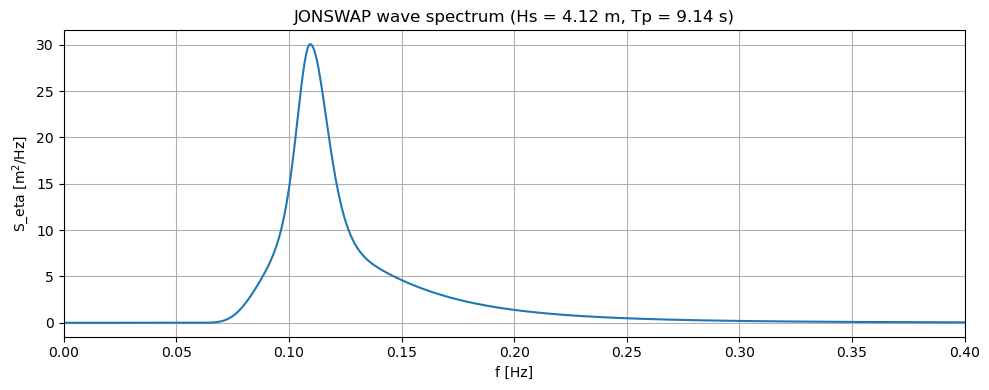

Hs check = 4*sqrt(m0) = 4.120 m


In [4]:
Hs_w, Tp_w, gamma = 4.12, 9.14, 3.3        # load case 2 (U10 = 19 m/s)

def S_eta_shape(f):
    """Un-normalised JONSWAP spectral shape."""
    f  = np.atleast_1d(f).astype(float)
    fp = 1/Tp_w
    sig = np.where(f <= fp, 0.07, 0.09)
    S = np.zeros_like(f)
    m = f > 1e-6
    r = np.exp(-(f[m]-fp)**2 / (2*sig[m]**2*fp**2))
    S[m] = (g**2 * (2*np.pi)**-4 * f[m]**-5
            * np.exp(-1.25*(fp/f[m])**4) * gamma**r)
    return S

_fg = np.linspace(1e-3, 1, 20000)
scale = (Hs_w / (4*np.sqrt(np.trapezoid(S_eta_shape(_fg), _fg))))**2

def S_eta(f):
    """One-sided wave-elevation PSD [m^2/Hz]."""
    return scale * S_eta_shape(f)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(_fg, S_eta(_fg))
ax.set_title(f'JONSWAP wave spectrum (Hs = {Hs_w} m, Tp = {Tp_w} s)')
ax.set_xlabel('f [Hz]'); ax.set_ylabel('S_eta [m$^2$/Hz]'); ax.set_xlim(0, 0.4)
plt.tight_layout()
fig.savefig(images / 'q4_wave_spectrum.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"Hs check = 4*sqrt(m0) = {4*np.sqrt(np.trapezoid(S_eta(_fg), _fg)):.3f} m")

## OWT finite-element model

The tower is discretised with 2-node Euler–Bernoulli beam elements (translation + rotation per
node). The submerged elements use cross-section 1, the elements in air use cross-section 2, and
the nacelle mass/inertia are lumped at the top node. **Rayleigh damping** is calibrated to give
$\xi_t=0.001$ at the first two natural frequencies. The base node (translation + rotation) is the
support: it is fixed for the wind/wave load cases and prescribed for the seismic base motion.

In [5]:
n_sub, n_air = 3, 9                              # elements below / above the waterline
z_nodes = np.concatenate([np.arange(n_sub+1)*(H_water/n_sub),
                          H_water + np.arange(1, n_air+1)*(H_air/n_air)])
n_nodes = len(z_nodes)
n_dof   = 2*n_nodes

def k_elem(le, EI):
    return EI/le**3 * np.array([[ 12,    6*le,   -12,    6*le],
                                [ 6*le,  4*le**2, -6*le, 2*le**2],
                                [-12,   -6*le,    12,   -6*le],
                                [ 6*le,  2*le**2, -6*le, 4*le**2]])

def m_elem(le, rA):
    return rA*le/420 * np.array([[156,   22*le,   54,   -13*le],
                                 [22*le, 4*le**2, 13*le, -3*le**2],
                                 [54,    13*le,   156,  -22*le],
                                 [-13*le,-3*le**2,-22*le, 4*le**2]])

K = np.zeros((n_dof, n_dof)); M = np.zeros((n_dof, n_dof))
for e in range(n_nodes-1):
    le = z_nodes[e+1] - z_nodes[e]
    z_mid = 0.5*(z_nodes[e] + z_nodes[e+1])
    A_, I_ = (A_sub, I_sub) if z_mid <= H_water else (A_air, I_air)
    dofs = [2*e, 2*e+1, 2*e+2, 2*e+3]
    Ke, Me = k_elem(le, E_t*I_), m_elem(le, rho_t*A_)
    for i in range(4):
        for j in range(4):
            K[dofs[i], dofs[j]] += Ke[i, j]
            M[dofs[i], dofs[j]] += Me[i, j]
M[n_dof-2, n_dof-2] += M_top      # lumped nacelle mass
M[n_dof-1, n_dof-1] += J_top      # lumped nacelle rotary inertia

free = np.arange(2, n_dof)        # all DOFs except the clamped base node (0, 1)
eigval, _ = eigh(K[np.ix_(free, free)], M[np.ix_(free, free)])
f_owt = np.sqrt(eigval)/(2*np.pi)

# Rayleigh damping matched to modes 1 and 2
w1, w2 = np.sqrt(eigval[0]), np.sqrt(eigval[1])
alpha = 2*xi_t*w1*w2/(w1+w2)
beta  = 2*xi_t/(w1+w2)
C = alpha*M + beta*K

# Base-moment recovery from the curvature of the first (base) element
i_top = 2*(n_nodes-1) - 2         # index of the top translation DOF within `free`
le0   = z_nodes[1] - z_nodes[0]
EI0   = E_t*I_sub
mom_recover = np.zeros(len(free)); mom_recover[0] = EI0*6/le0**2; mom_recover[1] = EI0*(-2)/le0

print(f"OWT natural frequencies [Hz]: {np.round(f_owt[:4], 3)}")

# Static (mean) response to the constant wind force
f_static = np.zeros(len(free)); f_static[i_top] = F_w
u_static = np.linalg.solve(K[np.ix_(free, free)], f_static)
mean_top = u_static[i_top]
mean_M   = mom_recover @ u_static
W_base   = I_sub/(9.1/2)           # elastic section modulus at the base
print(f"static wind: top displacement = {mean_top*1000:.1f} mm, "
      f"base moment = {mean_M/1e6:.2f} MNm")
print(f"base section modulus W = {W_base:.3f} m^3")

OWT natural frequencies [Hz]: [0.149 1.058 2.494 4.736]
static wind: top displacement = 187.8 mm, base moment = 36.20 MNm
base section modulus W = 4.449 m^3


## Q4.1 — Mean and variance of top displacement and base moment

**Seismic path.** The base motion is prescribed. Partitioning the dynamic stiffness
$\mathbf{D}(\omega)=-\omega^2\mathbf{M}+i\omega\mathbf{C}+\mathbf{K}$ into base (b) and free (f)
DOFs, a unit base displacement gives
$\mathbf{u}_f = -\mathbf{D}_{ff}^{-1}\mathbf{D}_{fb}$, from which the top displacement and base
moment FRFs follow. The base displacement PSD is the surface acceleration PSD divided by
$\omega^4$ (since $a=-\omega^2 u$):
$S_\text{surf}=|H_\text{soil}|^2\,S_\text{bedrock}$ and $S_{u_b}=S_\text{surf}/\omega^4$.

**Wave path.** Linear wave theory gives the horizontal water-particle acceleration per unit
wave-elevation amplitude as $\omega^2\cosh[k(z+h)]/\sinh(kh)$ (with $k$ from the dispersion
relation $\omega^2=gk\tanh kh$). The Morison **inertia** force per unit length is
$\rho_w C_m \tfrac{\pi D^2}{4}\,\ddot u_\text{water}$; it is distributed consistently over the
submerged elements and assumed fully coherent along the (short) submerged length.

Both transfer paths are extremely lightly damped, so the variance integrals
$\sigma^2=\int|H|^2 S\,df$ are evaluated on a frequency grid **refined around the soil and OWT
resonances**; grid convergence is checked afterwards.

In [6]:
# ---- Morison inertia wave loading on the submerged elements ----
rho_w, Cm, D_w, h_w = 1025., 2.0, 9.1, float(H_water)
submerged = [e for e in range(n_nodes-1) if 0.5*(z_nodes[e]+z_nodes[e+1]) <= H_water]

def wavenumber(om):
    """Solve the linear dispersion relation om^2 = g*k*tanh(k*h)."""
    return brentq(lambda k: om**2 - g*k*np.tanh(k*h_w), 1e-6, 5000.)

def depth_factor(z_swl, k, kh):
    """cosh(k(z+h))/sinh(kh) written in a numerically stable form (z measured from SWL)."""
    kz = k*z_swl
    return np.exp(kz)*(1 + np.exp(-2*(kz+kh)))/(1 - np.exp(-2*kh))

def frf_seismic(om):
    """(top displacement, base moment) per unit base displacement."""
    D = -om**2*M + 1j*om*C + K
    u = np.linalg.solve(D[np.ix_(free, free)], -D[np.ix_(free, [0])][:, 0])
    base_moment = EI0*(6/le0**2*(u[0] - 1.0) - 2/le0*u[1])   # base node moves with the support
    return u[i_top], base_moment

def frf_wave(om):
    """(top displacement, base moment) per unit wave-elevation amplitude."""
    k = wavenumber(om); kh = k*h_w
    D = -om**2*M + 1j*om*C + K
    f = np.zeros(n_dof, complex)
    for e in submerged:
        le = z_nodes[e+1] - z_nodes[e]
        da = 0.5*(depth_factor(z_nodes[e]-h_w, k, kh) + depth_factor(z_nodes[e+1]-h_w, k, kh))
        Fe = rho_w*Cm*np.pi*D_w**2/4 * om**2 * da * le      # inertia force amplitude on element
        f[2*e] += Fe/2; f[2*(e+1)] += Fe/2
    u = np.linalg.solve(D[np.ix_(free, free)], f[free])
    return u[i_top], mom_recover @ u

# ---- frequency grid, refined around the (very lightly damped) resonances ----
def refine(centres, half_width, n):
    return np.concatenate([np.linspace(c-half_width, c+half_width, n)
                           for c in centres if c-half_width > 0])

soil_modes = f_soil[1:-1][np.diff(np.sign(np.diff(H_soil_abs))) < 0][:6]   # peaks of |H_soil|
f_grid = np.unique(np.concatenate([np.linspace(0.02, 15, 2000),
                                   refine(soil_modes, 0.006, 1201),
                                   refine(f_owt[f_owt < 15], 0.03, 1201)]))
f_grid = f_grid[f_grid > 0.02]
om = 2*np.pi*f_grid

H_seis_top = np.zeros(len(f_grid), complex); H_seis_mom = np.zeros(len(f_grid), complex)
H_wave_top = np.zeros(len(f_grid), complex); H_wave_mom = np.zeros(len(f_grid), complex)
H_soil_sq  = np.zeros(len(f_grid))
for i, (f, w) in enumerate(zip(f_grid, om)):
    H_seis_top[i], H_seis_mom[i] = frf_seismic(w)
    if f < 1.0:                                   # wave energy is confined to f < ~0.3 Hz
        H_wave_top[i], H_wave_mom[i] = frf_wave(w)
    H_soil_sq[i] = abs(H_soil(w))**2

# ---- input PSDs on the grid ----
S_surf_acc  = S_bedrock(f_grid)*H_soil_sq    # surface acceleration PSD
S_surf_disp = S_surf_acc/om**4               # -> base displacement PSD
S_wave      = S_eta(f_grid)                  # wave-elevation PSD

def variance(H, S):
    return np.trapezoid(np.abs(H)**2*S, f_grid)

var_top_s, var_top_w = variance(H_seis_top, S_surf_disp), variance(H_wave_top, S_wave)
var_M_s,   var_M_w   = variance(H_seis_mom, S_surf_disp), variance(H_wave_mom, S_wave)
var_acc_s = variance(H_seis_top, S_surf_acc)                       # |H_disp|^2 * (om^4 S_disp)
var_acc_w = np.trapezoid(om**4*np.abs(H_wave_top)**2*S_wave, f_grid)

std_top = np.sqrt(var_top_s + var_top_w)
std_M   = np.sqrt(var_M_s + var_M_w)
std_acc = np.sqrt(var_acc_s + var_acc_w)

print("Q4.1 RESULTS  (mean = wind only; std = sqrt(seismic var + wave var))")
print(f"  top displacement : mean = {mean_top*1000:7.1f} mm | std = {std_top*1000:7.1f} mm"
      f"   (seismic {np.sqrt(var_top_s)*1000:.1f}, wave {np.sqrt(var_top_w)*1000:.1f})")
print(f"  base moment      : mean = {mean_M/1e6:7.2f} MNm| std = {std_M/1e6:7.2f} MNm"
      f"  (seismic {np.sqrt(var_M_s)/1e6:.2f}, wave {np.sqrt(var_M_w)/1e6:.2f})")
print(f"  top acceleration : mean =     0.0     | std = {std_acc:.3f} m/s^2  (zero-mean)")

# ---- grid-convergence check of the variance integrals ----
def variance_sub(H, S, step):
    return np.trapezoid((np.abs(H)**2*S)[::step], f_grid[::step])
for step in (1, 2, 4):
    s_top = np.sqrt(variance_sub(H_seis_top, S_surf_disp, step)
                    + variance_sub(H_wave_top, S_wave, step))
    print(f"  [convergence] every {step}th grid point -> std(top) = {s_top*1000:.1f} mm")

Q4.1 RESULTS  (mean = wind only; std = sqrt(seismic var + wave var))
  top displacement : mean =   187.8 mm | std =   467.1 mm   (seismic 3.6, wave 467.1)
  base moment      : mean =   36.20 MNm| std =  102.57 MNm  (seismic 5.98, wave 102.40)
  top acceleration : mean =     0.0     | std = 0.444 m/s^2  (zero-mean)
  [convergence] every 1th grid point -> std(top) = 467.1 mm
  [convergence] every 2th grid point -> std(top) = 467.0 mm
  [convergence] every 4th grid point -> std(top) = 467.2 mm


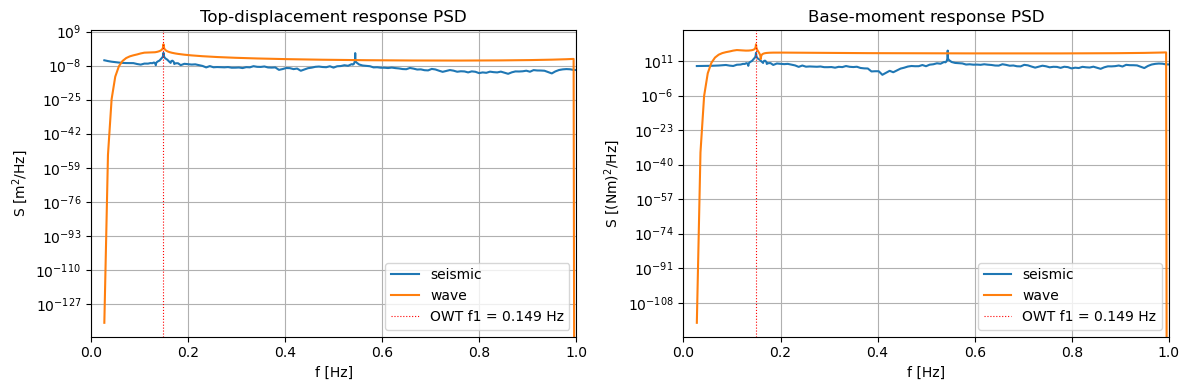

In [7]:
# Response PSDs (one-sided): which load dominates each response, and at what frequency
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].semilogy(f_grid, np.abs(H_seis_top)**2*S_surf_disp, label='seismic')
ax[0].semilogy(f_grid, np.abs(H_wave_top)**2*S_wave,      label='wave')
ax[0].axvline(f_owt[0], color='r', ls=':', lw=.8, label=f'OWT f1 = {f_owt[0]:.3f} Hz')
ax[0].set(title='Top-displacement response PSD', xlabel='f [Hz]',
          ylabel='S [m$^2$/Hz]', xlim=(0, 1)); ax[0].legend()
ax[1].semilogy(f_grid, np.abs(H_seis_mom)**2*S_surf_disp, label='seismic')
ax[1].semilogy(f_grid, np.abs(H_wave_mom)**2*S_wave,      label='wave')
ax[1].axvline(f_owt[0], color='r', ls=':', lw=.8, label=f'OWT f1 = {f_owt[0]:.3f} Hz')
ax[1].set(title='Base-moment response PSD', xlabel='f [Hz]',
          ylabel='S [(Nm)$^2$/Hz]', xlim=(0, 1)); ax[1].legend()
plt.tight_layout()
fig.savefig(images / 'q4_response_psd.png', bbox_inches='tight', dpi=200)
plt.show()

As we can see, the response is **wave-dominated**. The JONSWAP peak ($\approx0.11$ Hz) lies just
below the OWT fundamental (0.149 Hz); combined with the very light structural damping
($\xi_t=0.001$) this near-resonance is strongly amplified. The seismic contribution is much
smaller, which indicates that the bedrock motion is weak (induced seismicity) and, although amplified by the soft soil, its energy sits at the soil modes (~0.5–1.6 Hz), away from the OWT mode. The convergence printout
confirms the variance integrals are insensitive to grid refinement, which matters here because the
resonant peak is only ~$f/Q\approx3\times10^{-4}$ Hz wide.

## Q4.2 — Probabilities of exceedance (Gaussian response)

The response is assumed normally distributed. With the means from the static wind and the
standard deviations from Q4.1:

- **Base stress** $\sigma = M_\text{base}/W$ (mean from wind, std from the moment variance).
  Probability that $|\sigma|$ exceeds $0.8\,\sigma_y = 0.8\times355=284$ MPa.
- **Top acceleration** is zero-mean. Probability that $|a|$ exceeds $0.2\,g$.

In [8]:
mu_stress, std_stress = mean_M/W_base, std_M/W_base
threshold = 0.8*355e6
P_stress = norm.sf((threshold - mu_stress)/std_stress) + norm.cdf((-threshold - mu_stress)/std_stress)

a_threshold = 0.2*g
P_acc = 2*norm.sf(a_threshold/std_acc)

print("Q4.2 RESULTS")
print(f"  base stress : mean = {mu_stress/1e6:.2f} MPa, std = {std_stress/1e6:.2f} MPa, "
      f"threshold = {threshold/1e6:.0f} MPa")
print(f"      P(|sigma| > 0.8 sy)  = {P_stress:.2e}")
print(f"  top accel.  : std = {std_acc:.3f} m/s^2, threshold = 0.2 g = {a_threshold:.3f} m/s^2")
print(f"      P(|a_top| > 0.2 g)   = {P_acc:.2e}")

Q4.2 RESULTS
  base stress : mean = 8.14 MPa, std = 23.06 MPa, threshold = 284 MPa
      P(|sigma| > 0.8 sy)  = 2.72e-33
  top accel.  : std = 0.444 m/s^2, threshold = 0.2 g = 1.962 m/s^2
      P(|a_top| > 0.2 g)   = 9.97e-06


The base stress (mean ~8 MPa, std ~23 MPa) is far below yield, so the
probability of reaching 80 % of the yield limit is effectively zero, which means the structure is very safe
against yielding. The $0.2\,g$ top-acceleration limit is exceeded only with a small probability
($\sim10^{-5}$). Both dynamic magnitudes are resonance-dominated and therefore **sensitive to the
assumed damping**: $\xi_t=0.001$ is very light, and a more realistic 1–5 % would cut the dynamic
response by roughly an order of magnitude. The qualitative conclusions (safe against yield, rare
acceleration exceedance) are robust to that choice.

## Q4.3 — Are stationarity and ergodicity appropriate for the seismic motion?

The PSD was built assuming wide-sense stationarity (WSS) and ergodicity. Both are tested on the
record itself: the **windowed RMS** measures how much the signal energy varies in time, and the
**cumulative (Arias) energy** shows how concentrated the strong motion is.

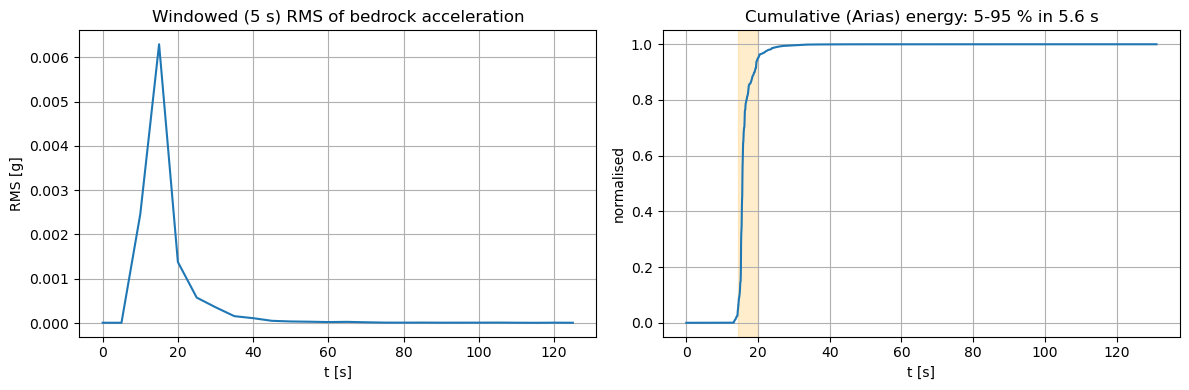

windowed RMS varies by 839x; strong-motion (5-95%) duration = 5.6 s out of 131 s


In [9]:
win = int(5/dt_s)
rms = np.array([prin[i:i+win].std() for i in range(0, len(prin)-win, win)])
t_win = np.arange(len(rms))*5

cum = np.cumsum(prin**2)/np.sum(prin**2)
t5  = t_sig[np.argmax(cum > 0.05)]
t95 = t_sig[np.argmax(cum > 0.95)]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(t_win, rms)
ax[0].set(title='Windowed (5 s) RMS of bedrock acceleration', xlabel='t [s]', ylabel='RMS [g]')
ax[1].plot(t_sig, cum); ax[1].axvspan(t5, t95, alpha=0.2, color='orange')
ax[1].set(title=f'Cumulative (Arias) energy: 5-95 % in {t95-t5:.1f} s',
          xlabel='t [s]', ylabel='normalised')
plt.tight_layout()
fig.savefig(images / 'q4_stationarity_ergodicity.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"windowed RMS varies by {rms.max()/rms.min():.0f}x; "
      f"strong-motion (5-95%) duration = {t95-t5:.1f} s out of {t_sig[-1]:.0f} s")

**Conclusion (4.3).** The record is strongly **non-stationary**: the windowed RMS varies by ~3
orders of magnitude and essentially all the energy arrives in a short ~5–6 s burst, so strict WSS
does not hold for the full signal. It remains a pragmatic engineering approximation, however
— the PSD captures the average frequency content of the strong-motion phase, which is what drives
the structure, so a stationary random-vibration analysis still gives reasonable response
statistics for design. Ergodicity cannot be verified from a single record (it needs an
ensemble of events); assuming it lets us replace the unavailable ensemble average by the time
average of one record. That is acceptable as an approximation but a genuine limitation, since each
induced event differs in magnitude, location and duration.

## Q4.4 — Can the horizontal and vertical seismic PSDs be assumed uncorrelated?

The dependence between the principal-horizontal and vertical components is measured both in the
time domain (zero-lag correlation coefficient) and in the frequency domain (magnitude-squared
coherence).

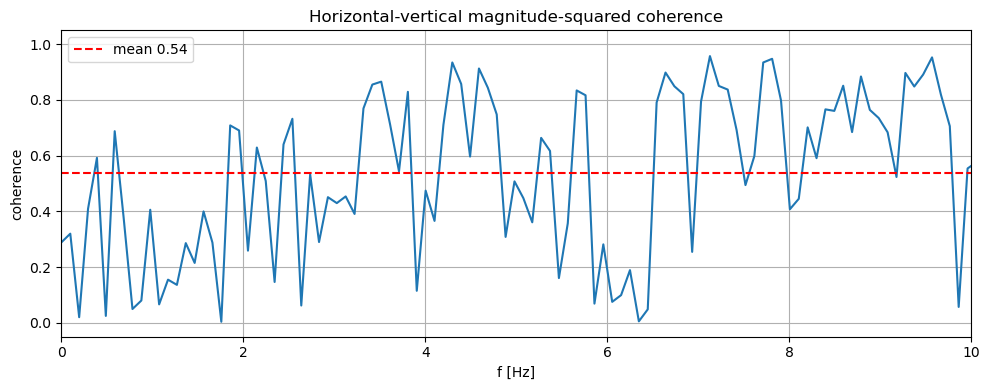

zero-lag correlation coef (H, V) = 0.110; mean coherence 0.1-10 Hz = 0.54


In [10]:
rho_hv = np.corrcoef(prin, vert - vert.mean())[0, 1]
f_coh, coh = coherence(prin, vert - vert.mean(), fs=fs, nperseg=2048)
band = (f_coh > 0.1) & (f_coh < 10)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(f_coh, coh)
ax.axhline(coh[band].mean(), color='r', ls='--', label=f'mean {coh[band].mean():.2f}')
ax.set_title('Horizontal-vertical magnitude-squared coherence')
ax.set_xlabel('f [Hz]'); ax.set_ylabel('coherence'); ax.set_xlim(0, 10); ax.legend()
plt.tight_layout()
fig.savefig(images / 'q4_hv_coherence.png', bbox_inches='tight', dpi=200)
plt.show()
print(f"zero-lag correlation coef (H, V) = {rho_hv:.3f}; "
      f"mean coherence 0.1-10 Hz = {coh[band].mean():.2f}")

**Conclusion (4.4).** The time-domain cross-correlation is weak ($\approx0.11$) but the spectral
coherence is moderate ($\approx0.5$), so the two components are not strictly uncorrelated.
Physically this is expected: although vertical motion is dominated by P-waves and horizontal
motion by SH/SV-waves, they share a common source, path and site, and near-surface Rayleigh
waves couple horizontal and vertical motion, producing frequency-dependent correlation. Treating
the two PSDs as uncorrelated is therefore a reasonable first approximation (justified by the
weak zero-lag correlation), but it neglects a real coupling; a rigorous treatment would use the
full cross-spectral density matrix of the three components, and the combined horizontal+vertical
demand could be somewhat underestimated by the uncorrelated assumption.